# Critical Potts entanglement-spectrum flow

This notebook calculates the half-chain entanglement spectrum of the critical three-state Potts chain for several system sizes and selected boundary conditions. Its main figure follows the numerical plotting convention used for the Potts data in Figure 5 of A. M. Läuchli, *Operator content of real-space entanglement spectra at conformal critical points*.

The default comparison is:

- an open chain with free boundaries (`free|free`); and
- a periodic chain (`periodic`).

Only finite-size scatter points are shown. To figure out the limiting values of the entanglement spectrum one would need a very large system size and also very large bond dimensions which is currently intractable on my laptop.

## 0. Imports

In [123]:
from pathlib import Path
from html import escape
import os
import sys
import time

from IPython.display import HTML, display
import matplotlib.pyplot as plt
import numpy as np
import tenpy
from tenpy.algorithms import dmrg
from tenpy.networks.mps import MPS


def find_project_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "potts_model_project", cwd.parent, cwd.parent / "potts_model_project"]
    for candidate in candidates:
        if (candidate / "potts_model" / "potts.py").is_file():
            return candidate
    raise RuntimeError("Could not locate the potts_model_project folder.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from potts_model import PottsChain

print("Project root:", PROJECT_ROOT)
print("TeNPy version:", tenpy.__version__)

Project root: /Users/Aditya/Desktop/Third Year Summer Project/potts_model_project
TeNPy version: 1.1.0


## 1. Definitions and Scaling

For a bipartition into regions $A$ and $B$, write the Schmidt decomposition as

$$
|\psi\rangle=\sum_\alpha s_\alpha |\alpha_A\rangle|\alpha_B\rangle.
$$

Here $s_\alpha$ is a **Schmidt value**. The corresponding eigenvalue of the reduced density matrix $\rho_A$ is

$$
\lambda_\alpha=s_\alpha^2,
$$

and this notebook defines the entanglement energy as

$$
\xi_\alpha=-\ln\lambda_\alpha=-2\ln s_\alpha.
$$

Thus, throughout this notebook, $\lambda$ means a reduced-density-matrix eigenvalue, **not** a Schmidt value.

For every boundary condition and every length $L$, sort the levels with multiplicity,

$$
\xi_0(L)\leq\xi_1(L)\leq\xi_2(L)\leq\cdots,
$$

then shift and rescale them as

$$
\widetilde\xi_n(L)=2\,\frac{\xi_n(L)-\xi_0(L)}{\xi_5(L)-\xi_0(L)}.
$$

For the free-boundary Potts spectrum, the expected first four **distinct level groups** are $0$, $2/3$, $5/3$, and $2$, with low-level multiplicities $1$, $2$, $2$, and $1$. The fourth distinct group is therefore the sixth sorted eigenvalue when multiplicity is counted, namely the zero-based entry $\xi_5$. Setting $\xi_5$ to 2 reproduces the normalization used for the three-state Potts spectra in Figure 5. A shift is necessary because the absolute entanglement-energy offset is non-universal; fixing one nonzero gap removes the remaining non-universal overall scale and allows spectra at different $L$ to be compared.

In the antiferromagnetic regime a different scaling has to be chosen but we cannot know what scaling to use before obtaining the data.

The horizontal coordinate is

$$
x_L=\frac{1}{\ln L}.
$$

Boundary-CFT arguments imply that the low entanglement gaps close approximately as $1/\ln L$, which is why the paper uses this variable. The thermodynamic limit would lie at $x_L=0$, but this notebook does not extrapolate to it.

## 2. Numerical parameters

In [124]:

L_values = [20, 50, 100, 150]
chi_max_values = [40, 100, 200, 300]
max_sweeps = 100

J = -1.0
h = -1.0
svd_min = 1e-11
max_E_err = 1e-9

n_levels_to_store = 40
n_levels_to_plot = 24
reference_rank = 5       # sixth eigenvalue = fourth distinct Potts level group
reference_value = 2.0

if any(L % 2 for L in L_values):
    raise ValueError("All L_values must be even for an equal half-chain cut.")
if any(L < 4 for L in L_values):
    raise ValueError("Every entry in L_values must be an integer of at least 4.")
if len(chi_max_values) != len(L_values):
    raise ValueError("chi_max_values must have the same length as L_values.")
if any(chi <= 0 for chi in chi_max_values):
    raise ValueError("Every entry in chi_max_values must be positive.")

run_configs = list(zip(L_values, chi_max_values))
if len(set(run_configs)) != len(run_configs):
    raise ValueError("Each (L, chi_max) pair must be unique.")
if n_levels_to_store <= reference_rank:
    raise ValueError("n_levels_to_store must include the reference level.")

print("Smoke test:", SMOKE_TEST)
print("Runs (L, chi_max):", run_configs)
print("J = h =", J)
print("max_sweeps:", max_sweeps)

Smoke test: False
Runs (L, chi_max): [(20, 40), (50, 100), (100, 200), (150, 300)]
J = h = -1.0
max_sweeps: 100


## 3. Boundary-condition selection

The reusable `PottsChain` accepts `1`, `2`, or `3` for a fixed edge; `-1`, `-2`, or `-3` for an edge that forbids that state; and `"free"` for a free edge. Edit only `selected_case_labels` to compare a different subset.

For the periodic case, `order="default"` is intentional. The central MPS cut must divide the physical ring into the two contiguous half-chains used in the paper. A folded MPS order makes the Hamiltonian cheaper but changes which physical sites lie on each side of the central MPS cut.

In [125]:
all_boundary_cases = {
    "free|free": {"left": "free", "right": "free"},
    "1|1": {"left": 1, "right": 1},
    "1|2": {"left": 1, "right": 2},
    "1|3": {"left": 1, "right": 3},
    "1|-1": {"left": 1, "right": -1},
    "1|-2": {"left": 1, "right": -2},
    "1|free": {"left": 1, "right": "free"},
    "-1|-1": {"left": -1, "right": -1},
    "-1|-2": {"left": -1, "right": -2},
    "-1|free": {"left": -1, "right": "free"},
    "periodic": {
        "left": "free",
        "right": "free",
        "periodic": True,
        "order": "default",
    },
}

selected_case_labels = ["free|free", "periodic"]

unknown_labels = set(selected_case_labels) - set(all_boundary_cases)
if unknown_labels:
    raise KeyError(f"Unknown boundary labels: {sorted(unknown_labels)}")

boundary_cases = {
    label: all_boundary_cases[label]
    for label in selected_case_labels
}

boundary_cases

{'free|free': {'left': 'free', 'right': 'free'},
 'periodic': {'left': 'free',
  'right': 'free',
  'periodic': True,
  'order': 'default'}}

## 4. Entanglement-spectrum helpers

TeNPy's direct entanglement spectrum is checked against $-2\ln s_\alpha$ from the central Schmidt values. The code also verifies that the density-matrix weights sum to one and that they reconstruct the central von Neumann entropy.

In [126]:
def central_entanglement_spectrum(psi):
    """Return all finite xi=-log(lambda) values at the equal half-chain cut."""
    if psi.L % 2:
        raise ValueError("Use an even L for an equal half-chain cut.")
    cut = psi.L // 2 - 1
    xi = np.asarray(psi.entanglement_spectrum()[cut], dtype=float)
    return np.sort(xi[np.isfinite(xi)])


def central_spectrum_from_schmidt_values(psi):
    """Independently calculate xi=-2 log(s) from central Schmidt values."""
    s = np.asarray(psi.get_SL(psi.L // 2), dtype=float)
    s = s[np.isfinite(s) & (s > 0.0)]
    return np.sort(-2.0 * np.log(s))


def normalize_spectrum(xi, rank, target=reference_value):
    """Shift xi[0] to zero and set xi[rank] to target."""
    xi = np.sort(np.asarray(xi, dtype=float))
    if len(xi) <= rank:
        raise ValueError(f"Need at least {rank + 1} levels for this normalization.")
    gap = xi[rank] - xi[0]
    if not np.isfinite(gap) or gap <= 1e-12:
        raise ValueError("The selected reference gap is zero or numerically unstable.")
    return target * (xi - xi[0]) / gap


def validate_central_spectrum(psi, xi, atol=2e-10):
    xi_from_s = central_spectrum_from_schmidt_values(psi)
    if len(xi) != len(xi_from_s) or not np.allclose(xi, xi_from_s, atol=atol, rtol=atol):
        raise RuntimeError("TeNPy's direct spectrum disagrees with -2 log(Schmidt values).")

    lambdas = np.exp(-xi)
    lambda_sum = float(np.sum(lambdas))
    entropy_from_spectrum = float(np.sum(lambdas * xi))
    central_entropy = float(psi.entanglement_entropy()[psi.L // 2 - 1])

    if not np.isclose(lambda_sum, 1.0, atol=2e-10, rtol=2e-10):
        raise RuntimeError(f"Central density-matrix eigenvalues sum to {lambda_sum}, not 1.")
    if not np.isclose(entropy_from_spectrum, central_entropy, atol=2e-10, rtol=2e-10):
        raise RuntimeError("The spectrum does not reconstruct the central entropy.")

    return {
        "lambda_sum": lambda_sum,
        "entropy_from_spectrum": entropy_from_spectrum,
        "central_entropy": central_entropy,
    }

## 5. Model builder and DMRG runner

The Hamiltonian uses the reusable project convention with $J=h=1$, the ferromagnetic critical point. The spectrum is taken at the cut between physical sites $L/2-1$ and $L/2$. For the periodic chain this produces a contiguous interval of length $L/2$ with two entanglement boundaries.

In [127]:
class DMRGProgressBar:
    """In-place Jupyter progress display updated at TeNPy sweep checkpoints."""

    def __init__(self, label, L, chi_max, configured_max_sweeps, width=28):
        self.label = label
        self.L = L
        self.chi_max = chi_max
        self.configured_max_sweeps = configured_max_sweeps
        # TeNPy 1.1.0 checks its stopping condition after sweeps > max_sweeps.
        self.total_sweeps = configured_max_sweeps + 1
        self.width = width
        self.start_time = time.perf_counter()
        self.handle = display(self._render(0, 1, "starting"), display_id=True)

    def _render(self, sweeps, achieved_chi, status):
        fraction = min(max(sweeps / self.total_sweeps, 0.0), 1.0)
        filled = round(self.width * fraction)
        bar = "█" * filled + "░" * (self.width - filled)
        elapsed = time.perf_counter() - self.start_time
        text = (
            f"{self.label} | L={self.L} | chi_max={self.chi_max} | "
            f"sweep {sweeps}/{self.total_sweeps} [{bar}] {100 * fraction:5.1f}% | "
            f"current chi={achieved_chi} | {elapsed:,.1f} s | {status}"
        )
        return HTML(f"<pre style='margin:0.25em 0'>{escape(text)}</pre>")

    def update(self, engine, status="running"):
        achieved_chi = max(engine.psi.chi) if len(engine.psi.chi) else 1
        rendered = self._render(engine.sweeps, achieved_chi, status)
        if self.handle is None:
            print(rendered.data, flush=True)
        else:
            self.handle.update(rendered)

    def at_checkpoint(self, engine):
        self.update(engine)


def build_model(L, case):
    return PottsChain.from_parameters(
        L=L,
        J=J,
        h=h,
        left_boundary=case["left"],
        right_boundary=case["right"],
        periodic=case.get("periodic", False),
        order=case.get("order", "default"),
    )


def run_dmrg_for_case(L, chi_for_L, label, case):
    model = build_model(L, case)
    if J>0:
        initial_state = model.initial_product_state(bulk_state=1)
    else:
        initial_state = ["1" if i % 2 == 0 else "2" for i in range(model.lat.N_sites)]
    psi = MPS.from_product_state(
        model.lat.mps_sites(),
        initial_state,
        bc=model.lat.bc_MPS,
        unit_cell_width=model.lat.mps_unit_cell_width,
    )

    dmrg_params = {
        "mixer": True,
        "max_sweeps": max_sweeps,
        "N_sweeps_check": 1,
        "max_E_err": max_E_err,
        "max_N_sites_per_ring": model.lat.N_sites,
        "trunc_params": {
            "chi_max": chi_for_L,
            "svd_min": svd_min,
        },
    }

    engine = dmrg.TwoSiteDMRGEngine(psi, model, dmrg_params)
    progress = DMRGProgressBar(label, L, chi_for_L, max_sweeps)
    engine.checkpoint.connect(progress.at_checkpoint)
    try:
        energy, psi = engine.run()
    except Exception:
        progress.update(engine, status="failed")
        raise

    if engine.shelve:
        final_status = "stopped at time limit"
    elif engine.is_converged():
        final_status = "converged"
    else:
        final_status = "sweep limit reached"
    progress.update(engine, status=final_status)

    xi_all = central_entanglement_spectrum(psi)
    checks = validate_central_spectrum(psi, xi_all)
    xi = xi_all[:n_levels_to_store]

    return {
        "label": label,
        "case": case,
        "L": L,
        "chi_max_requested": chi_for_L,
        "model": model,
        "psi": psi,
        "energy": float(np.real(energy)),
        "energy_per_site": float(np.real(energy) / L),
        "xi_raw": xi,
        "xi_shifted": xi - xi[0],
        "xi_scaled": normalize_spectrum(
            xi,
            rank=reference_rank,
            target=reference_value,
        ),
        "x_inv_log_L": 1.0 / np.log(L),
        "checks": checks,
        "chi": list(psi.chi),
    }

## 6. Run all selected cases

This is the expensive cell. Each entry of `chi_max_values` is paired with the entry at the same position in `L_values`. A run is identified by its `(L, chi_max)` pair, so the same system size may appear more than once with different bond dimensions. Runtime grows with the number of boundary cases, the system sizes, the selected bond dimensions, and `max_sweeps`.

The in-place bar updates after each completed sweep and reports the current achieved bond dimension and elapsed time. It measures sweep progress rather than estimated wall-clock progress. TeNPy 1.1.0 tests its stopping condition after `sweeps > max_sweeps`, so an unconverged run can complete and display `max_sweeps + 1` sweeps.

In [128]:
results = {label: {} for label in selected_case_labels}

for label, case in boundary_cases.items():
    for L, chi_for_L in run_configs:
        print(f"Running {label:>10}, L={L:>3}, chi_max={chi_for_L} ...", flush=True)
        result = run_dmrg_for_case(L, chi_for_L, label, case)
        results[label][(L, chi_for_L)] = result
        print(
            f"  E/L={result['energy_per_site']:.10f}, "
            f"max chi={max(result['chi'])}, "
            f"sum(lambda)={result['checks']['lambda_sum']:.12f}"
        )

print("Done.")

Running  free|free, L= 20, chi_max=40 ...


  E/L=-0.5938128317, max chi=40, sum(lambda)=1.000000000000
Running  free|free, L= 50, chi_max=100 ...


  E/L=-0.6007066272, max chi=100, sum(lambda)=1.000000000000
Running  free|free, L=100, chi_max=200 ...


  E/L=-0.6030263581, max chi=200, sum(lambda)=1.000000000000
Running  free|free, L=150, chi_max=300 ...


KeyboardInterrupt: 

## 7. Numerical diagnostics

These checks establish internal consistency, not convergence in $L$ or bond dimension. In particular, a successful row does not mean that its higher entanglement levels are quantitatively converged.

In [119]:
print(
    f"{'boundary':>10} {'L':>4} {'chi cap':>8} {'E/L':>15} {'max chi':>9} "
    f"{'sum(lambda)':>14} {'S spectrum - S TeNPy':>22}"
)
print("-" * 91)

for label in selected_case_labels:
    for L, chi_for_L in run_configs:
        result = results[label][(L, chi_for_L)]
        checks = result["checks"]
        entropy_difference = checks["entropy_from_spectrum"] - checks["central_entropy"]
        print(
            f"{label:>10} {L:4d} {chi_for_L:8d} {result['energy_per_site']:15.10f} "
            f"{max(result['chi']):9d} {checks['lambda_sum']:14.11f} "
            f"{entropy_difference:22.3e}"
        )

  boundary    L  chi cap             E/L   max chi    sum(lambda)   S spectrum - S TeNPy
-------------------------------------------------------------------------------------------
 free|free   50       40   -0.6007065993        40  1.00000000000              0.000e+00
 free|free   50      100   -0.6007066272       100  1.00000000000             -2.220e-16
  periodic   50       40   -0.6053851394        40  1.00000000000             -2.220e-16
  periodic   50      100   -0.6054454870       100  1.00000000000              0.000e+00


## 8. Raw shifted spectra

Before interpreting a normalized plot, inspect the unscaled gaps $\xi_n-\xi_0$. This makes a very small or unstable normalization denominator easier to notice. Every selected `(L, chi_max)` run is shown so that bond-dimension and size dependence can be compared directly.

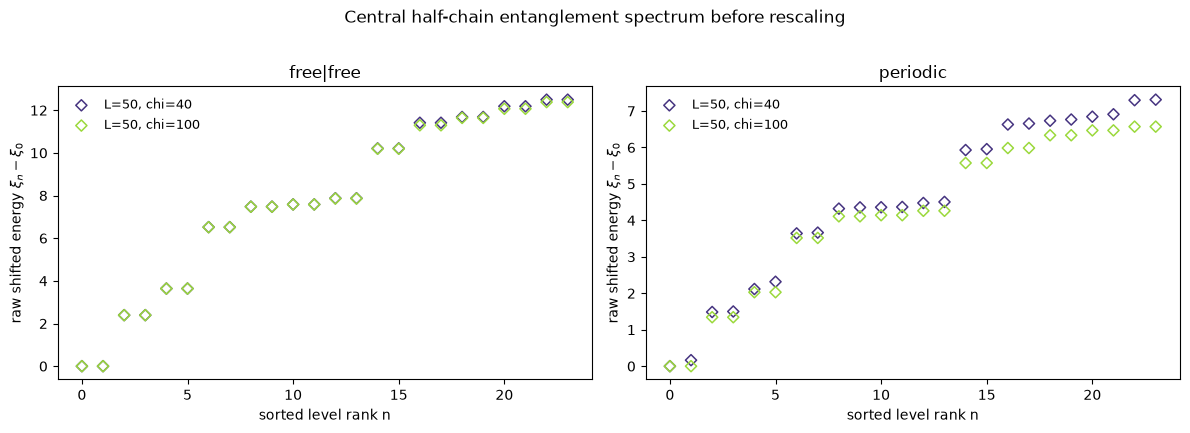

In [122]:
fig, axes = plt.subplots(1, len(selected_case_labels), figsize=(6.0 * len(selected_case_labels), 4.2), squeeze=False)
ordered_runs = sorted(run_configs, key=lambda config: (config[0], config[1]))
run_colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(ordered_runs)))

for ax, label in zip(axes.ravel(), selected_case_labels):
    for colour, config in zip(run_colours, ordered_runs):
        result = results[label][config]
        y = result["xi_shifted"][:n_levels_to_plot]
        ax.scatter(
            np.arange(len(y)), y,
            marker="D", s=32, facecolors="none", edgecolors=[colour], linewidths=1.1,
            label=f"L={result['L']}, chi={result['chi_max_requested']}",
        )
    ax.set_title(label)
    ax.set_xlabel("sorted level rank n")
    ax.set_ylabel(r"raw shifted energy $\xi_n-\xi_0$")
    ax.legend(frameon=False, fontsize=9)

fig.suptitle("Central half-chain entanglement spectrum before rescaling", y=1.02)
fig.tight_layout()

## 9. Figure-5-style finite-size spectrum flow

Each vertical column is the low entanglement spectrum for one $L$. The plotted quantity is

$$
\widetilde\xi_n(L)=2\frac{\xi_n(L)-\xi_0(L)}{\xi_5(L)-\xi_0(L)},
\qquad x_L=\frac{1}{\ln L}.
$$

Only points are drawn. Equal sorted ranks are **not** connected between sizes because crossings and finite-size splittings can change their ordering. No fitted or extrapolated levels are added.

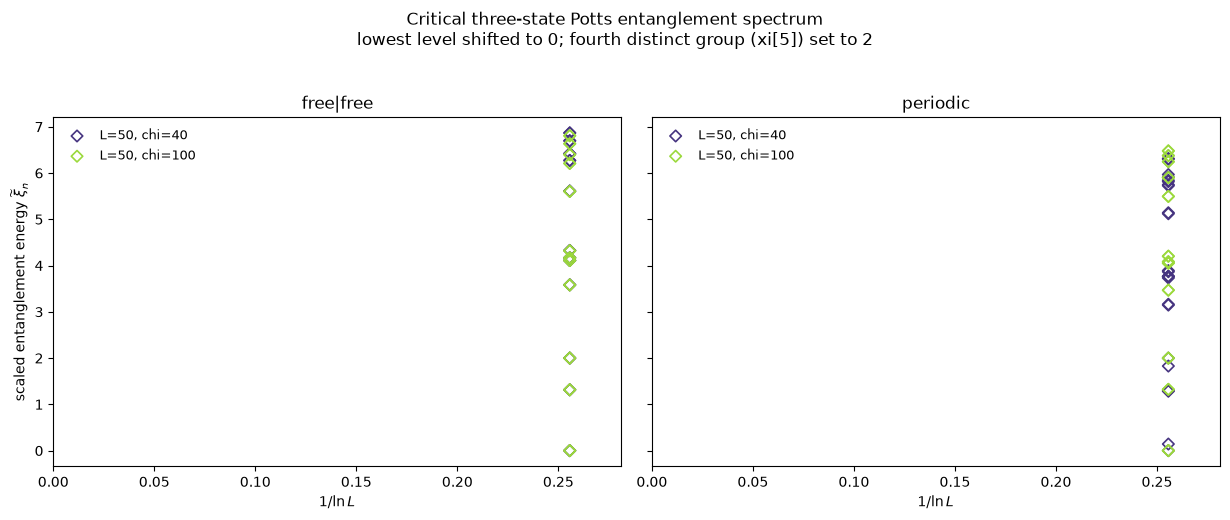

In [121]:
fig, axes = plt.subplots(
    1, len(selected_case_labels),
    figsize=(6.2 * len(selected_case_labels), 5.0),
    sharey=True,
    squeeze=False,
)

ordered_runs = sorted(run_configs, key=lambda config: (config[0], config[1]))
run_colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(ordered_runs)))

for ax, label in zip(axes.ravel(), selected_case_labels):
    available = [results[label][config] for config in ordered_runs]
    number_to_show = min(n_levels_to_plot, *(len(result["xi_scaled"]) for result in available))

    for colour, result in zip(run_colours, available):
        y = result["xi_scaled"][:number_to_show]
        x = np.full(number_to_show, result["x_inv_log_L"])
        ax.scatter(
            x, y,
            marker="D", s=34,
            facecolors="none", edgecolors=[colour], linewidths=1.2,
            label=f"L={result['L']}, chi={result['chi_max_requested']}",
        )

    ax.set_xlim(0.0, max(result["x_inv_log_L"] for result in available) * 1.10)
    ax.set_xlabel(r"$1/\ln L$")
    ax.set_title(label)
    ax.legend(frameon=False, fontsize=9)

axes[0, 0].set_ylabel(r"scaled entanglement energy $\widetilde{\xi}_n$")
fig.suptitle(
    "Critical three-state Potts entanglement spectrum\n"
    "lowest level shifted to 0; fourth distinct group (xi[5]) set to 2",
    y=1.03,
)
fig.tight_layout()

## 10. Interpretation limits

At this stage the plot reveals only coarse finite-size trends. Much more computational power would be needed to be able to extract valuable information.

- The fourth-distinct-group normalization is applied separately at each $L$ and for each boundary condition. For the free-boundary Potts spectrum this group is expected at $2$ and corresponds to `xi[5]` after counting the lower multiplicities. It fixes a common plotting convention; it does not by itself prove that the selected level belongs to the same conformal branch in every finite system.
- Low-lying levels generally converge before high levels. Increasing `n_levels_to_plot` can therefore display levels that are poorly converged even when the DMRG energy looks stable.